In [1]:
#import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
# Load Dataset
iris = load_iris()

In [3]:
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target

In [32]:
# Dataset Info
print("First 5 Rows")
print(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nColumn Names")
print(df.columns)

print("\nTarget Classes")
print(iris.target_names)

print("\nDataset Information")
print(df.info())

print("\nStatistical Summary")
print(df.describe())

First 5 Rows
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  

Dataset Shape
(149, 5)

Column Names
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'species'],
      dtype='object')

Target Classes
['setosa' 'versicolor' 'virginica']

Dataset Information
<class 'pandas.core.frame.DataFrame'>
Index: 149 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  ----- 

In [28]:
# Null values
print("Missing Values")
print(df.isnull().sum())

Missing Values
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [6]:
#Print Duplicate Rows
print("Dataset Shape:", df.shape)
print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (150, 5)

Duplicate Rows: 1


In [7]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Duplicate Rows After Removal:", df.duplicated().sum())

# Check new dataset shape
print("Dataset Shape:", df.shape)

Duplicate Rows After Removal: 0
Dataset Shape: (149, 5)


In [9]:
# Assign columns for testing and training
X = df.drop("species", axis=1)
y = df["species"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
# Logistic Regression
model = LogisticRegression(max_iter=200)

model.fit(X_train, y_train)

LogisticRegression(max_iter=200)

In [12]:
y_pred = model.predict(X_test)

In [29]:
print("Logistic Regression Results")

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1-Score :", f1_score(y_test, y_pred, average="weighted"))

Logistic Regression Results
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0


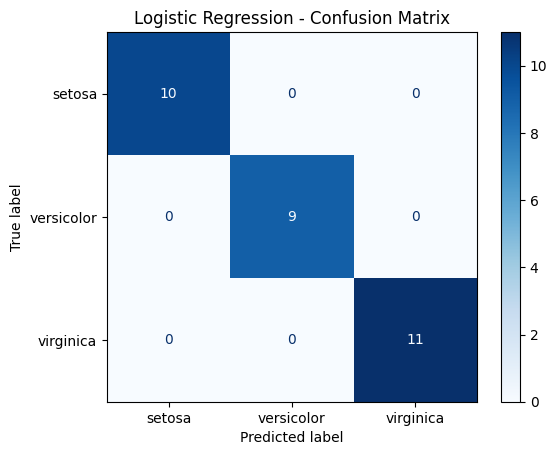

In [14]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot(cmap="Blues")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [30]:
print("Sample Predictions")

for i in range(10):
    print(
        "Actual:", iris.target_names[y_test.iloc[i]],
        "| Predicted:", iris.target_names[y_pred[i]]
    )

Sample Predictions
Actual: versicolor | Predicted: versicolor
Actual: setosa | Predicted: setosa
Actual: virginica | Predicted: virginica
Actual: versicolor | Predicted: versicolor
Actual: versicolor | Predicted: versicolor
Actual: setosa | Predicted: setosa
Actual: versicolor | Predicted: versicolor
Actual: virginica | Predicted: virginica
Actual: versicolor | Predicted: versicolor
Actual: versicolor | Predicted: versicolor


In [16]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [17]:
dt_y_pred = dt_model.predict(X_test)

In [18]:
print("Decision Tree Results")

print("Accuracy :", accuracy_score(y_test, dt_y_pred))
print("Precision:", precision_score(y_test, dt_y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, dt_y_pred, average="weighted"))
print("F1-Score :", f1_score(y_test, dt_y_pred, average="weighted"))

Decision Tree Results
---------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-Score : 1.0


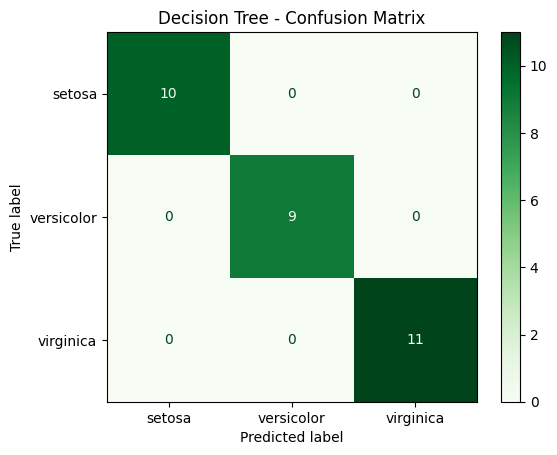

In [19]:
cm = confusion_matrix(y_test, dt_y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot(cmap="Greens")
plt.title("Decision Tree - Confusion Matrix")
plt.show()